# Single Agent Tutorial

1. Raw LLMs

2. Tools Calling LLMs

3. ReAct Agents

---
## 1 - Setup & API Key Verification

In [ ]:
# Install dependencies
!pip install -q openai langgraph langchain-openai langchain-core

import os
from getpass import getpass
from openai import OpenAI

from google.colab import userdata
userdata.get('OPENAI_API_KEY')

# Verify the key works
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

try:
    models = client.models.list()
    gpt_models = [m.id for m in models.data if "gpt" in m.id][:5]
    print("API key valid.")
    print(f"Sample models: {gpt_models}")
except Exception as e:
    print(f"API key verification failed: {e}")

---
## 2 - Why Do We Need Tools?

Ask the LLM about today's weather: a question that requires real-time data it doesn't have.

In [ ]:
from openai import OpenAI

# A question requiring real-time knowledge
question = "What is the weather in Bangalore right now? Should I carry an umbrella today?"

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user",   "content": question}
    ]
)

print(f"Question: {question}")
print(f"\nLLM Answer:\n{response.choices[0].message.content}")

---
## 3 - Using the built-in Web Search Tool

OpenAI's Responses API ships with a built-in `web_search` tool.

The LLM decides to search, reads results, and synthesize an answer.

```
  User question
     |
     v
  LLM decides -> "I need live data" -> calls web_search
     |
     v
  Tool returns search results
     |
     v
  LLM reads results -> formulates answer with citations
```

In [ ]:
from openai import OpenAI

# Same question, now with web_search enabled
question = "What is the weather in Bangalore right now? Should I carry an umbrella today? Mention time in IST and temperature in Celsius, F in (brackets)."

response = client.responses.create(
    model="gpt-4o-mini",
    tools=[{"type": "web_search"}],   # one line to enable web search
    input=question
)

print(f"Question: {question}\n")
print("Answer (with web search):")
print(response.output_text)

# Show the tool calls that happened under the hood
print("\n-- Agent trace --")
for item in response.output:
    print(f"  Step type: {item.type}")

In [ ]:
from openai import OpenAI

question = "What is the weather in Bangalore right now? Should I carry an umbrella today?"

response = client.responses.create(
    model="gpt-4o-mini",
    tools=[{"type": "web_search"}],
    input=question
)

# Response metadata
print(f"Model: {response.model} | Status: {response.status}\n")

# Walk through each output item
for i, item in enumerate(response.output):
    print(f"Step {i+1}: {item.type}")

    if item.type == "web_search_call":
        print(f"  Status: {item.status}")
        if hasattr(item, "action") and item.action:
            print(f"  Query: {item.action.query}")

    elif item.type == "message":
        for block in item.content:
            if block.type == "output_text":
                print(f"\n  Answer (truncated): {block.text[:200]}...")
                if block.annotations:
                    print(f"\n  Citations: {len(block.annotations)} sources")
                    for ann in block.annotations[:3]:
                        if ann.type == "url_citation":
                            print(f"    [{ann.start_index}:{ann.end_index}] {ann.title}")

# Token usage
if response.usage:
    print(f"\nTokens: input={response.usage.input_tokens}, "
          f"output={response.usage.output_tokens}, "
          f"total={response.usage.total_tokens}")

---
## 4 - Writing Custom Tool Descriptions for OpenAI

Built-in tools cover web search, code, and files.

For your own APIs, you describe each function as a JSON schema.

The LLM reads the name, description, and parameter schema to decide when and how to call it.

Two custom tools below: currency exchange ([exchangerate-api](https://open.er-api.com/)) and weather forecast ([Open-Meteo](https://open-meteo.com/)). Both free, no API keys needed.

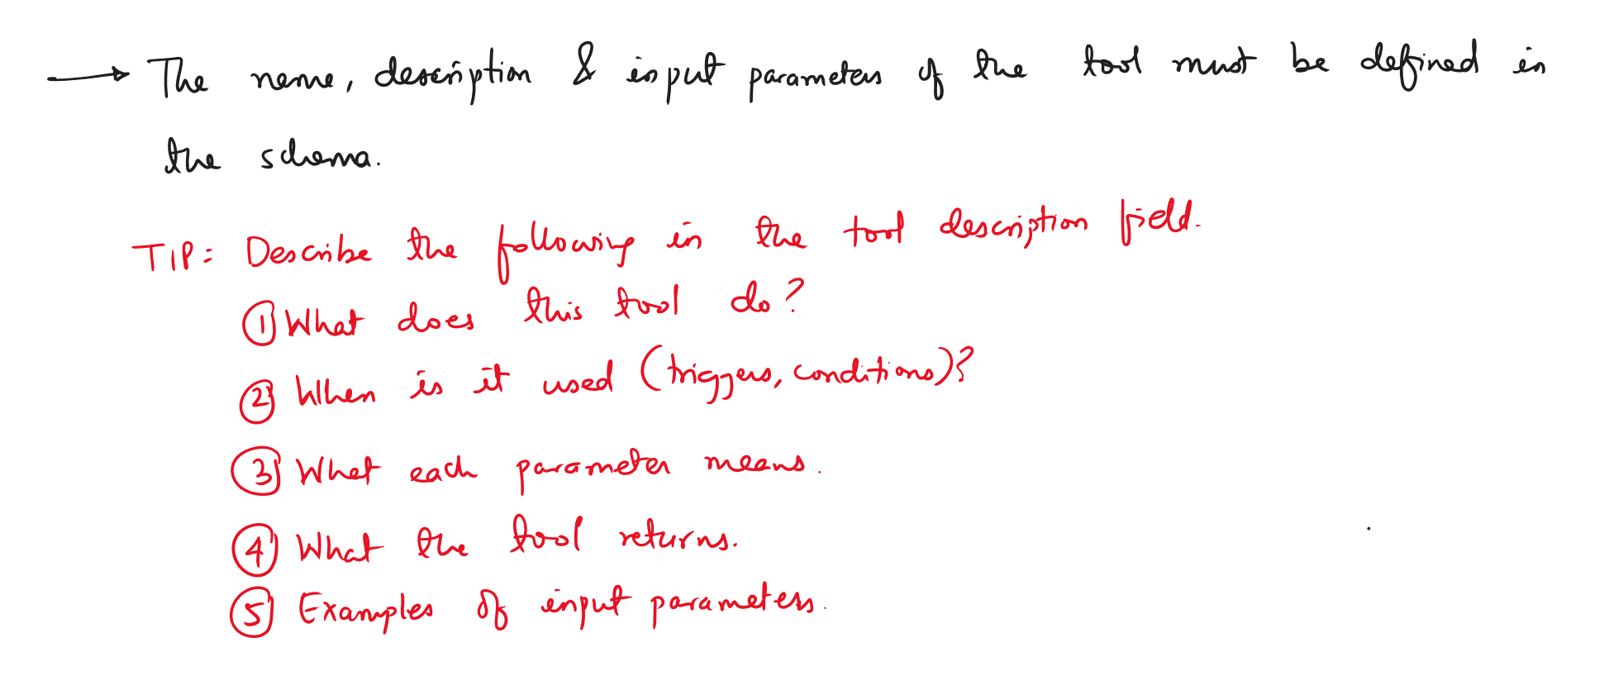

In [ ]:
import json
import urllib.request
import urllib.parse
from openai import OpenAI

# STEP 1: Tool descriptions (what the LLM sees)
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_exchange_rate",
            "description": (
                "Get the current exchange rate between two currencies. "
                "Use this whenever the user asks about currency conversion or exchange rates. "
                "Returns the rate as a float (e.g., 1 USD = 83.5 INR returns 83.5)."
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "base":   {"type": "string", "description": "The source currency code, e.g. USD, EUR, GBP"},
                    "target": {"type": "string", "description": "The target currency code, e.g. INR, JPY, AUD"}
                },
                "required": ["base", "target"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": (
                "Get the current weather and forecast for any city. "
                "Use this for any question about weather, temperature, or forecasts."
                "Returns temperature, humidity, rain probability, and wind speed. "
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "city": {"type": "string", "description": "City name, e.g. 'Bangalore', 'London', 'Tokyo'"},
                    "days": {"type": "integer", "description": "Number of forecast days (1-7). Default is 3."}
                },
                "required": ["city"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "search_hotels",
            "description": (
                "Get hotels bookable for a city."
                "Use for any question about hotel search."
                "Returns list of hotels that can be booked. "
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "city": {"type": "string", "description": "City name, e.g. 'Bangalore', 'London', 'Tokyo'"},
                },
                "required": ["city"]
            }
        }
    }
]

# STEP 2: Function implementations
def get_exchange_rate(base: str, target: str) -> str:
    """Calls the free exchangerate-api to get live rates."""
    try:
        url = f"https://open.er-api.com/v6/latest/{base.upper()}"
        with urllib.request.urlopen(url, timeout=5) as r:
            data = json.loads(r.read())
        rate = data["rates"].get(target.upper())
        if rate is None:
            return json.dumps({"error": f"Currency '{target}' not found."})
        return json.dumps({"base": base.upper(), "target": target.upper(), "rate": rate})
    except Exception as e:
        return json.dumps({"error": str(e)})


def search_hotels(city: str) -> str:
    """
    Get hotels bookable for a city.
    Use for any question about hotel search.

    Args:
        city:   City to search hotels in, e.g. 'Tokyo', 'London', 'Bengaluru'
    """
    return "Hotels in Tokyo are at rates 100$, 200$ and 500$"

def get_weather(city: str, days: int = 3) -> str:
    """Geocodes city via Open-Meteo, then fetches current conditions + daily forecast."""
    try:
        # Geocode city to coordinates
        geo_url = (
            f"https://geocoding-api.open-meteo.com/v1/search"
            f"?name={urllib.parse.quote(city)}&count=1&language=en&format=json"
        )
        with urllib.request.urlopen(geo_url, timeout=5) as r:
            geo = json.loads(r.read())

        if not geo.get("results"):
            return json.dumps({"error": f"City '{city}' not found."})

        loc = geo["results"][0]
        lat, lon, name = loc["latitude"], loc["longitude"], loc["name"]

        # Fetch current conditions + daily forecast
        weather_url = (
            f"https://api.open-meteo.com/v1/forecast"
            f"?latitude={lat}&longitude={lon}"
            f"&current=temperature_2m,relative_humidity_2m,weather_code,wind_speed_10m"
            f"&daily=temperature_2m_max,temperature_2m_min,precipitation_probability_max,"
            f"wind_speed_10m_max,weather_code"
            f"&forecast_days={days}&timezone=auto"
        )
        with urllib.request.urlopen(weather_url, timeout=5) as r:
            wx = json.loads(r.read())

        current = wx["current"]
        daily = wx["daily"]
        forecast = []
        for i in range(days):
            forecast.append({
                "date":            daily["time"][i],
                "temp_max_c":      daily["temperature_2m_max"][i],
                "temp_min_c":      daily["temperature_2m_min"][i],
                "rain_chance_pct": daily["precipitation_probability_max"][i],
                "wind_max_kmh":    daily["wind_speed_10m_max"][i],
            })

        return json.dumps({
            "city": name,
            "current": {
                "temperature_c": current["temperature_2m"],
                "humidity_pct":  current["relative_humidity_2m"],
                "wind_kmh":      current["wind_speed_10m"],
                "weather_code":  current["weather_code"],
            },
            "forecast": forecast
        })
    except Exception as e:
        return json.dumps({"error": str(e)})

# Map name to function for dispatch
tool_registry = {
    "get_exchange_rate": get_exchange_rate,
    "get_weather":       get_weather,
    "search_hotels": search_hotels,
}

# STEP 3: Run the agent loop manually
user_message = "What is 14312423 USD in INR, and what's the weather in Bangalore? Should I wear a hat?"
messages = [
    {"role": "system", "content": "You are a helpful assistant. Use tools when needed."},
    {"role": "user",   "content": user_message}
]

print(f"User: {user_message}\n")

# Turn 1: LLM decides which tools to call
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=messages,
    tools=tools
)
msg = response.choices[0].message
messages.append(msg)

print(f"LLM wants to call {len(msg.tool_calls)} tool(s):")
for tc in msg.tool_calls:
    print(f"  -> {tc.id}{tc.function.name}({tc.function.arguments})")

# Turn 2: Execute each tool and feed results back
for tc in msg.tool_calls:
    fn_name = tc.function.name
    fn_args = json.loads(tc.function.arguments)
    result  = tool_registry[fn_name](**fn_args)
    print(f"\nTool result [{fn_name}]:\n  {result}")
    messages.append({"role": "tool", "tool_call_id": tc.id, "content": result})

# Turn 3: LLM formulates final answer using tool results
final = client.chat.completions.create(model="gpt-4o-mini", messages=messages)
print(f"\nFinal Answer:\n{final.choices[0].message.content}")

---
## OPTIONAL 5 - Enter LangGraph: API-Agnostic Tool Descriptions

Instead of OpenAI's JSON schema format, LangGraph uses the `@tool` decorator. Your tool code stays the same regardless of which model provider you swap in.

| | OpenAI function calling | LangGraph `@tool` |
|--|--|--|
| Description format | JSON schema dict | Python docstring |
| Provider lock-in | OpenAI only | Any provider |
| Agent loop | Manual | Automatic |
| Streaming | Manual | Built-in |

In [ ]:
import json
import urllib.request
import urllib.parse

from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

# Same tools, now described with @tool and docstrings.
# LangGraph reads the docstring as the tool description.
# Swap ChatOpenAI for ChatAnthropic and everything below works unchanged.

@tool
async def weather_forecast(city: str, days: int = 3) -> str:
    """
    Get a real weather forecast for any city in the world.
    Returns daily temperature range, rain probability, and wind speed.
    Use for any question about current or upcoming weather.

    Args:
        city: City name, e.g. 'Bangalore', 'Mumbai', 'London'
        days: Number of forecast days (1 to 7). Default is 3.
    """
    try:
        geo_url = (
            f"https://geocoding-api.open-meteo.com/v1/search"
            f"?name={urllib.parse.quote(city)}&count=1&language=en&format=json"
        )
        with urllib.request.urlopen(geo_url, timeout=5) as r:
            geo = json.loads(r.read())
        if not geo.get("results"):
            return f"City '{city}' not found."
        loc = geo["results"][0]
        lat, lon, name = loc["latitude"], loc["longitude"], loc["name"]

        wx_url = (
            f"https://api.open-meteo.com/v1/forecast"
            f"?latitude={lat}&longitude={lon}"
            f"&daily=temperature_2m_max,temperature_2m_min,precipitation_probability_max,wind_speed_10m_max"
            f"&forecast_days={days}&timezone=auto"
        )
        with urllib.request.urlopen(wx_url, timeout=5) as r:
            wx = json.loads(r.read())

        daily = wx["daily"]
        lines = [f"Weather forecast for {name}:"]
        for i in range(days):
            lines.append(
                f"  {daily['time'][i]}: "
                f"{daily['temperature_2m_min'][i]}-{daily['temperature_2m_max'][i]}C, "
                f"rain chance {daily['precipitation_probability_max'][i]}%, "
                f"wind {daily['wind_speed_10m_max'][i]} km/h"
            )
        return "\n".join(lines)
    except Exception as e:
        return f"Error fetching weather: {e}"


@tool
async def exchange_rate(base: str, target: str) -> str:
    """
    Get the current exchange rate between two currencies.
    Use for any question about currency conversion or exchange rates.

    Args:
        base:   Source currency code, e.g. 'USD', 'EUR', 'GBP'
        target: Target currency code, e.g. 'INR', 'JPY', 'AUD'
    """
    try:
        url = f"https://open.er-api.com/v6/latest/{base.upper()}"
        with urllib.request.urlopen(url, timeout=5) as r:
            data = json.loads(r.read())
        rate = data["rates"].get(target.upper())
        if rate is None:
            return f"Currency '{target}' not supported."
        return f"1 {base.upper()} = {rate} {target.upper()}"
    except Exception as e:
        return f"Error fetching exchange rate: {e}"

@tool
async def search_hotels(city: str) -> str:
    """
    Get hotels bookable for a city.
    Use for any question about hotel search.

    Args:
        city:   City to search hotels in, e.g. 'Tokyo', 'London', 'Bengaluru'
    """
    return "Hotels in Tokyo are at rates 1$, 2$ and 500$"


# Build the agent: 3 lines instead of a manual loop
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=userdata.get("OPENAI_API_KEY")
)

agent = create_react_agent(model=llm, tools=[weather_forecast, exchange_rate])

# Question that requires BOTH tools: LangGraph handles the loop
question = "What's the weather in London this week, and what is 200 GBP in INR? Should I wear a hat?"
print(f"User: {question}\n")

result = agent.invoke({"messages": [{"role": "user", "content": question}]})

# Show every step the agent took
print("-- Agent trace --")
for msg in result["messages"]:
    label = msg.__class__.__name__
    content = str(msg.content)[:120].strip()
    if content:
        print(f"[{label:20s}] {content}")

print(f"\nFinal Answer:\n{result['messages'][-1].content}")

---
## 6 - The ReAct Pattern: A Simple Agent Loop

LangGraph is convenient, but the core pattern is a simple while loop you can write yourself. The ReAct (Reason + Act) loop:

1. Send messages + tool definitions to the LLM
2. If the LLM returns tool calls: execute them, append results, loop back to step 1
3. If the LLM returns plain text: done, that's the final answer

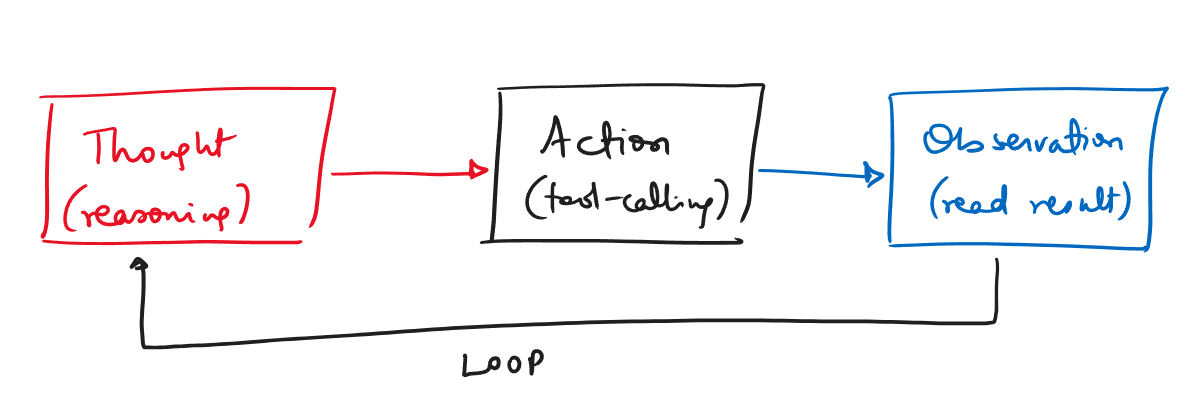

In [ ]:
import json
from openai import OpenAI

def run_agent(user_input: str, max_iterations: int = 5):
    messages = [
        {"role": "system", "content": "You are a helpful assistant. Use tools when needed."},
        {"role": "user", "content": user_input}
    ]


    for i in range(max_iterations):
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=messages,
            tools=tools
        )
        msg = response.choices[0].message
        messages.append(msg)

        # No tool calls -> LLM is done reasoning, return answer
        if not msg.tool_calls:
            print(f"\nFinal Answer:\n{msg.content}")
            return msg.content

        # Execute each tool call, feed results back into messages
        print(f"[Iteration {i+1}] LLM calls {len(msg.tool_calls)} tool(s):")
        for tc in msg.tool_calls:
            fn_name = tc.function.name
            fn_args = json.loads(tc.function.arguments)
            print(f"  -> {fn_name}({fn_args})")

            result = tool_registry[fn_name](**fn_args)
            print(f"  <- {result[:100]}")

            messages.append({
                "role": "tool",
                "tool_call_id": tc.id,
                "content": result
            })
        # Loop back: LLM sees tool results and decides next step

    print("Max iterations reached.")
    return messages[-1].content


# Test: a question requiring multiple tools
question = "What's the weather in Tokyo and how much is 1000 JPY in USD? Based on this response, would a small hotel be bookable with this amount with USD?"
print(f"User: {question}\n")
run_agent(question)